In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

In [2]:
df = pd.read_csv('tugas_genap.csv')

# Exploratory Data Analysis (EDA)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   game_name    2000 non-null   object 
 1   meta_score   2000 non-null   float64
 2   user_score   2000 non-null   float64
 3   platform     2000 non-null   object 
 4   description  1980 non-null   object 
 5   url          2000 non-null   object 
 6   developer    1998 non-null   object 
 7   genre        1999 non-null   object 
 8   type         1571 non-null   object 
 9   rating       1696 non-null   object 
dtypes: float64(2), object(8)
memory usage: 156.4+ KB
None


In [4]:
print(df.describe(include='all'))

                                   game_name   meta_score   user_score  \
count                                   2000  2000.000000  2000.000000   
unique                                  2000          NaN          NaN   
top     The Legend of Zelda: Ocarina of Time          NaN          NaN   
freq                                       1          NaN          NaN   
mean                                     NaN    80.854000    76.765000   
std                                      NaN     5.179392    10.225804   
min                                      NaN    74.000000    12.000000   
25%                                      NaN    77.000000    73.000000   
50%                                      NaN    80.000000    78.000000   
75%                                      NaN    83.000000    84.000000   
max                                      NaN    99.000000    92.000000   

       platform                                        description  \
count      2000                          

In [15]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 game_name        0
meta_score       0
user_score       0
platform         0
description      0
url              0
developer        0
genre            0
type           429
rating         304
combined         0
dtype: int64


In [5]:
print("\nJumlah Data Duplikat:", df.duplicated().sum())


Jumlah Data Duplikat: 0


# Visualisasi

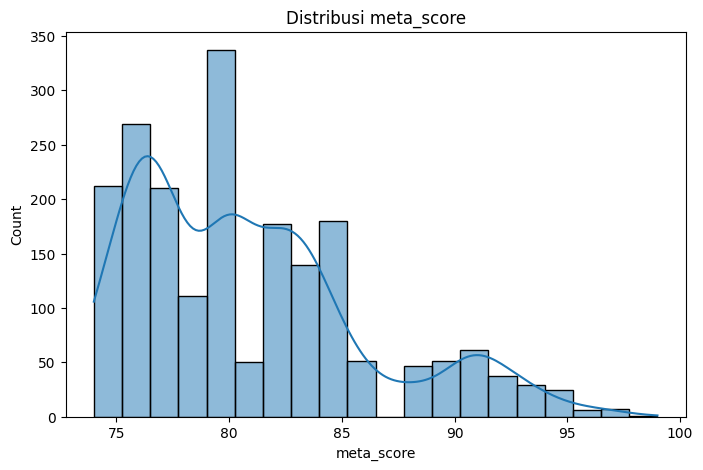

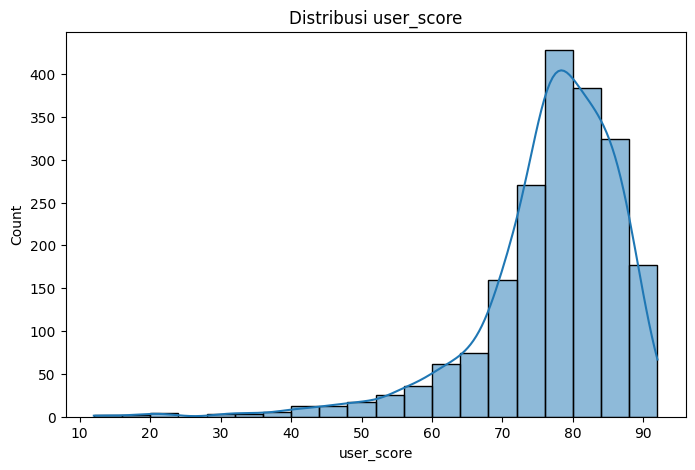

In [6]:
for col in ['meta_score', 'user_score']:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribusi {col}')
    plt.show()

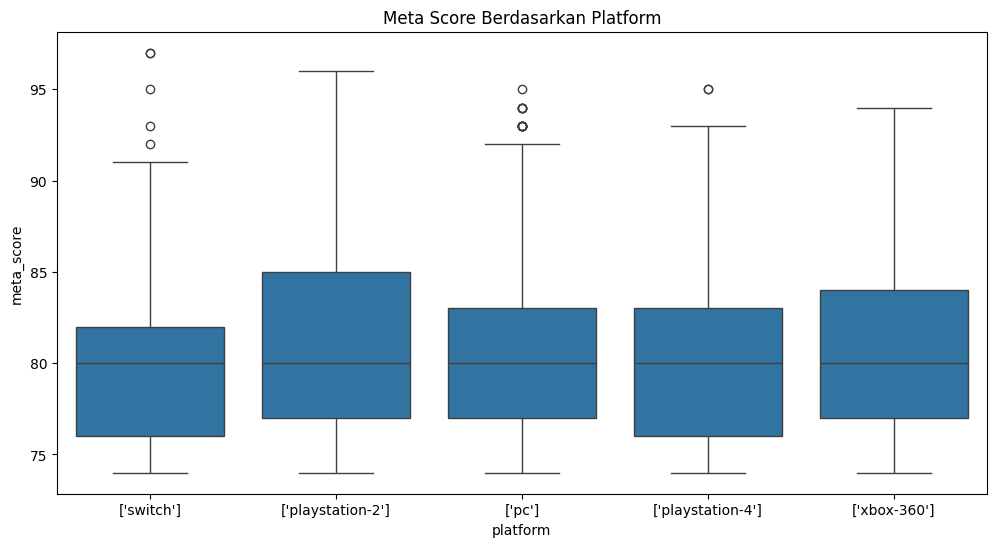

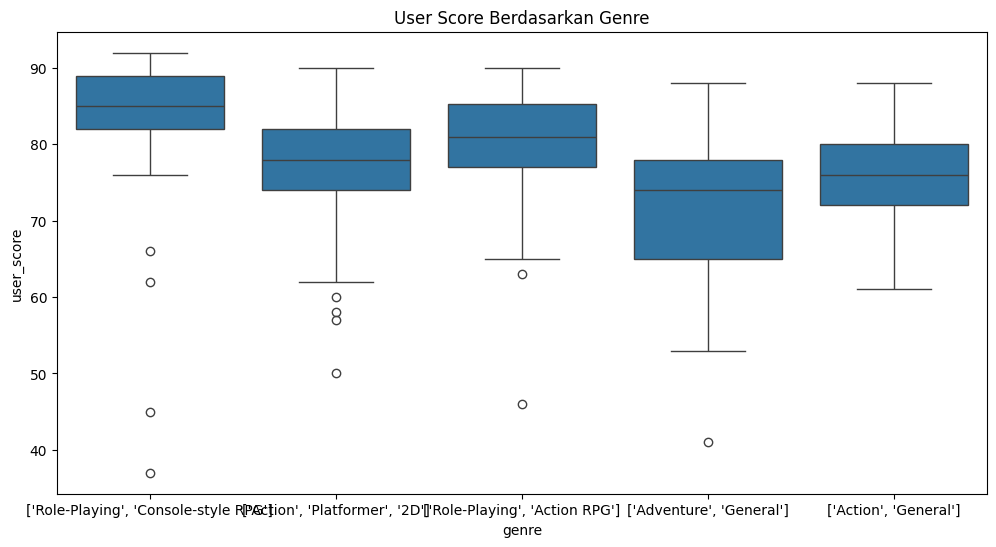

In [7]:
top_platforms = df['platform'].value_counts().head(5).index
top_genres = df['genre'].value_counts().head(5).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['platform'].isin(top_platforms)], x='platform', y='meta_score')
plt.title('Meta Score Berdasarkan Platform')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['genre'].isin(top_genres)], x='genre', y='user_score')
plt.title('User Score Berdasarkan Genre')
plt.show()


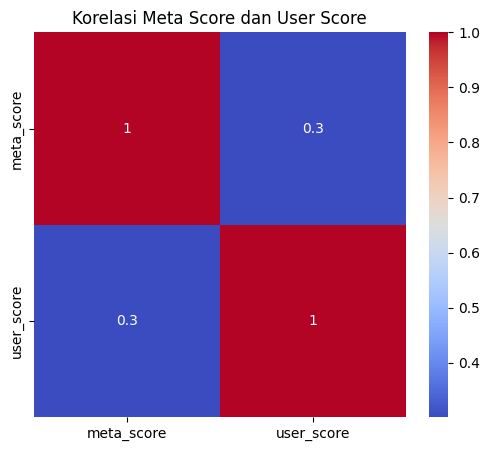

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['meta_score', 'user_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Meta Score dan User Score')
plt.show()

# Content Based Recommender System

In [9]:
df['description'] = df['description'].fillna('')
df['genre'] = df['genre'].fillna('')
df['platform'] = df['platform'].fillna('')
df['developer'] = df['developer'].fillna('')
df['game_name'] = df['game_name'].fillna('')

df['combined'] = df[['game_name', 'genre', 'platform', 'developer', 'description']].agg(' '.join, axis=1)

In [10]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])

In [11]:
distance_matrix = euclidean_distances(tfidf_matrix, tfidf_matrix)

In [12]:
indices = pd.Series(df.index, index=df['game_name']).drop_duplicates()

In [13]:
def recommend_games(title, top_k=5):
    if title not in indices:
        return f"Game '{title}' tidak ditemukan dalam dataset."
    
    idx = indices[title]
    distances = list(enumerate(distance_matrix[idx]))
    distances = sorted(distances, key=lambda x: x[1])[1:top_k+1]
    
    print(f"Rekomendasi untuk '{title}':")
    for i, (index, dist) in enumerate(distances, 1):
        print(f"{i}. {df.loc[index, 'game_name']} (Jarak: {dist:.2f})")

In [16]:
recommend_games("Super Mario Galaxy", 5)

Rekomendasi untuk 'Super Mario Galaxy':
1. Super Mario 3D World (Jarak: 1.09)
2. Mario Kart Wii (Jarak: 1.13)
3. Super Mario Galaxy 2 (Jarak: 1.13)
4. Super Mario 3D All-Stars (Jarak: 1.13)
5. Super Mario Odyssey (Jarak: 1.18)
